<div align="center">
  <img src="fotos/logo_utem.png" alt="Logo UTEM" width="120" style="max-height:140px; height:auto;"/>
  <br><br>

  <p style="margin:2px 0; font-size:16px; font-weight:400; text-shadow:none;">UNIVERSIDAD TECNOLOGICA METROPOLITANA</p>
  <p style="margin:2px 0; font-size:14px; font-weight:400; text-shadow:none;">INGENIERIA CIVIL EN CIENCIA DE DATOS</p>
  <p style="margin:2px 0; font-size:14px; font-weight:400; text-shadow:none;">INFB8090 - COMPUTACION PARALELA Y DISTRIBUIDA</p>

  <br><br>
  <h2 style="margin:0;">LABORATORIO N 3</h2>
  <br>
  <h1 style="margin:0;"><i>Concurrencia en Python. Procesos, hilos, async y benchmarking comparativo</i></h1>

  <br><br>
  <p style="margin:2px 0;">Profesor: Michael Miranda Sandoval</p>
  <p style="margin:2px 0;">Integrante: Diego Silva Madariaga</p>
  <p style="margin:2px 0;">Fecha: 23 de abril de 2026</p>
</div>

In [15]:
import time
import random
import math
import pandas as pd
import matplotlib.pyplot as plt
from concurrent.futures import ThreadPoolExecutor, ProcessPoolExecutor

### Ejercicio 1 distingir carga CPU-bound e I/O-bound


Caso CPU-bound e Hilos GIL

Se ejecuta una funcion matematica de entropia sintetica la cual realiza iteraciones continuas y pesadas para estresar la cpu y asi crear una carga CPU-bound, ademas se mide y compara el tiempo que demora procesar grandes volumenes de datos de forma secuencial versus el uso de hilos. 

Esto tiene como objetivo demostrar que debido al GIL de Python los hilos no logran ejecutarse en paralelo verdadero para tareas de calculo.

N=5000 | Secuencial: 0.0622s | Hilos: 0.0585s
N=10000 | Secuencial: 0.1211s | Hilos: 0.1235s
N=20000 | Secuencial: 0.2495s | Hilos: 0.2401s
N=40000 | Secuencial: 0.4755s | Hilos: 0.4923s


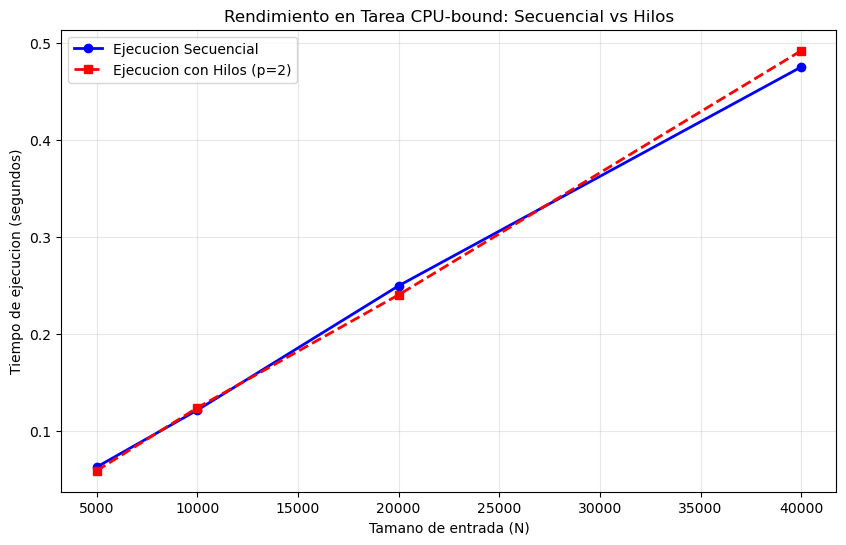

In [8]:
def procesar_entropia_sintetica(datos):
    # operacion matematica intensiva repetida
    resultado = []
    for x in datos:
        val = x
        for _ in range(50):
            # Transformacion trigonometrica y logaritmica pesada
            val = math.sqrt(math.log1p(math.fabs(math.sin(val) + 1.1))) + math.pow(val, 0.1)
        resultado.append(val)
    return resultado

def ejecutar_pruebas_y_graficar():
    tamanos = [5000, 10000, 20000, 40000]
    tiempos_sec = []
    tiempos_hilos = []
    
    for n in tamanos:
        datos_prueba = [i * 0.001 for i in range(n)]
        
        # Secuencial
        inicio = time.perf_counter()
        procesar_entropia_sintetica(datos_prueba)
        t_seq = time.perf_counter() - inicio
        tiempos_sec.append(t_seq)
        
        # Hilos 
        mitad = n // 2
        parte1 = datos_prueba[:mitad]
        parte2 = datos_prueba[mitad:]
        
        inicio = time.perf_counter()
        with ThreadPoolExecutor(max_workers=2) as executor:
            executor.submit(procesar_entropia_sintetica, parte1)
            executor.submit(procesar_entropia_sintetica, parte2)
        t_hilos = time.perf_counter() - inicio
        tiempos_hilos.append(t_hilos)
        
        print(f"N={n} | Secuencial: {t_seq:.4f}s | Hilos: {t_hilos:.4f}s")

    plt.figure(figsize=(10, 6))
    
    plt.plot(tamanos, tiempos_sec, marker='o', color='blue', label='Ejecucion Secuencial', linewidth=2)
    plt.plot(tamanos, tiempos_hilos, marker='s', color='red', label='Ejecucion con Hilos (p=2)', linewidth=2, linestyle='--')
    
    plt.title('Rendimiento en Tarea CPU-bound: Secuencial vs Hilos')
    plt.xlabel('Tamano de entrada (N)')
    plt.ylabel('Tiempo de ejecucion (segundos)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.show()

if __name__ == "__main__":
    ejecutar_pruebas_y_graficar()

Caso I/O-bound e Hilos

Para este caso se simula multiples consultas a una base de datos externa usando pausas controladas para representar la latencia de la red creando asi una tarea puramente I/O-bound, se procesa estas consultas de forma secuencial y luego utilizando un pool de hilos para medir y graficar la diferencia de rendimiento. 

Esto tiene como objetivo probar que a diferencia de las tareas de procesamiento puro, en operaciones dominadas por la espera el uso de hilos si deberia reducir  los tiempos totales, ya que mientras un hilo espera pasivamente una respuesta, libera el GIL y permite que otros hilos envien peticiones al mismo tiempo.

N=5 | Secuencial: 1.4686s | Hilos: 0.3864s
N=10 | Secuencial: 2.9646s | Hilos: 0.6904s
N=15 | Secuencial: 4.4145s | Hilos: 0.8773s
N=20 | Secuencial: 6.1621s | Hilos: 1.4455s


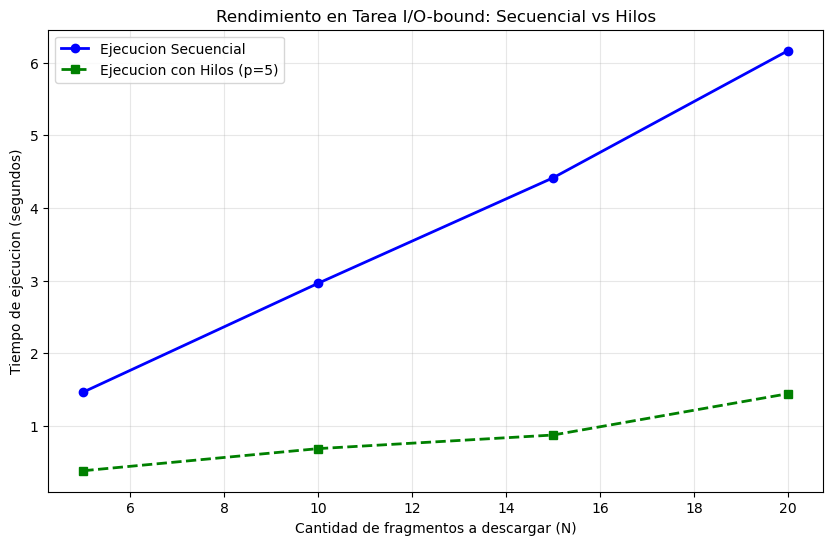

In [9]:
def descargar_fragmento_api(id_fragmento):
    # Simula latencia de red al consultar un servidor externo 
    tiempo_espera = random.uniform(0.2, 0.4)
    time.sleep(tiempo_espera)
    return id_fragmento * 10

def ejecutar_pruebas_io():
    cantidades = [5, 10, 15, 20]
    tiempos_sec = []
    tiempos_hilos = []
    
    for n in cantidades:
        fragmentos = list(range(n))

        # Secuencial
        inicio = time.perf_counter()
        for f in fragmentos:
            descargar_fragmento_api(f)
        t_sec = time.perf_counter() - inicio
        tiempos_sec.append(t_sec)
        
        #  Hilos 
        inicio = time.perf_counter()
        with ThreadPoolExecutor(max_workers=5) as executor:
            list(executor.map(descargar_fragmento_api, fragmentos))
        t_hilos = time.perf_counter() - inicio
        tiempos_hilos.append(t_hilos)
        
        print(f"N={n} | Secuencial: {t_sec:.4f}s | Hilos: {t_hilos:.4f}s")

    plt.figure(figsize=(10, 6))
    
    plt.plot(cantidades, tiempos_sec, marker='o', color='blue', label='Ejecucion Secuencial', linewidth=2)
    plt.plot(cantidades, tiempos_hilos, marker='s', color='green', label='Ejecucion con Hilos (p=5)', linewidth=2, linestyle='--')
    
    plt.title('Rendimiento en Tarea I/O-bound: Secuencial vs Hilos')
    plt.xlabel('Cantidad de fragmentos a descargar (N)')
    plt.ylabel('Tiempo de ejecucion (segundos)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.show()

if __name__ == "__main__":
    ejecutar_pruebas_io()

Al observar los resultados se ve la diferencia de comportamiento entre ambos escenarios y se demuestra el impacto del Global Interpreter Lock en Python.

En la tarea CPU-bound la linea de ejecucion secuencial y la de hilos se superponen casi por completo tomando el mismo tiempo a medida que crecen los datos. Esto porque la tarea exige un esfuerzo puramente matematico del procesador y debido al GIL de Python solo se permite que un hilo ejecute instrucciones a la vez, impidiendo un paralelismo real, los hilos no trabajan todos al mismo tiempo por lo que no hay ganancia de velocidad e incluso puede haber un leve retraso por el costo de alternar entre ellos.

Para la tarea I/O-bound se muestra como la ejecucion con hilos supera a la version secuencial. Al ser una tarea con pausas y esperas por la simulacion de latencia de red el procesador esta inactivo gran parte del tiempo, aqui cuando un hilo entra en estado de espera libera el GIL voluntariamente y permite que los demas hilos tomen el control e inicien sus propias descargas simultaneamente.

Por lo que la estrategia de hilos en Python es inutil para acelerar calculos pesados pero es la herramienta perfecta y definitiva para optimizar tareas limitadas por tiempos de espera y acceso a recursos externos.

### Ejercicio 2 Comparar hilos y procesos en una tarea intensiva


El objetivo es proponer una tarea CPU-bound de computo intensivo dividida en unidades independientes, comparando ejecucion secuencial,hilos y con procesos

Para esto se simula una tarea basada en la simulacion de Monte Carlo, un metodo estadistico que resuelve problemas mediante probabilidad, aqui el algoritmo genera millones de pares de coordenadas aleatorias (x, y) que representan por ejemplo dardos lanzados a un tablero. Por cada par se aplica una formula geometrica para verificar si el dardo cayo dentro de un circulo unitario. Esta carga de trabajo se agrupa en lotes masivos de millones de iteraciones donde cada lote es una unidad de procesamiento completamente independiente del resto.

Esto se concidera CPU-bound porque el tiempo total de ejecucion depende de manera exclusiva de la velocidad y capacidad de calculo del procesador y a diferencia de las tareas I/O-bound este algoritmo no tiene tiempos muertos. El procesador es sometido a un estres maximo y continuo de operaciones aritmeticas y logicas.

Condicion del circulo:
$$x^2 + y^2 \le 1$$


CPU-bound con  simulacion monte carlo

     Configuracion  N Lotes  Secuencial (s)  Hilos (s)  Procesos (s)
Carga Ligera (N=4)        4          1.1447     1.1493        0.4139
Carga Pesada (N=8)        8          2.2722     2.3264        0.7597


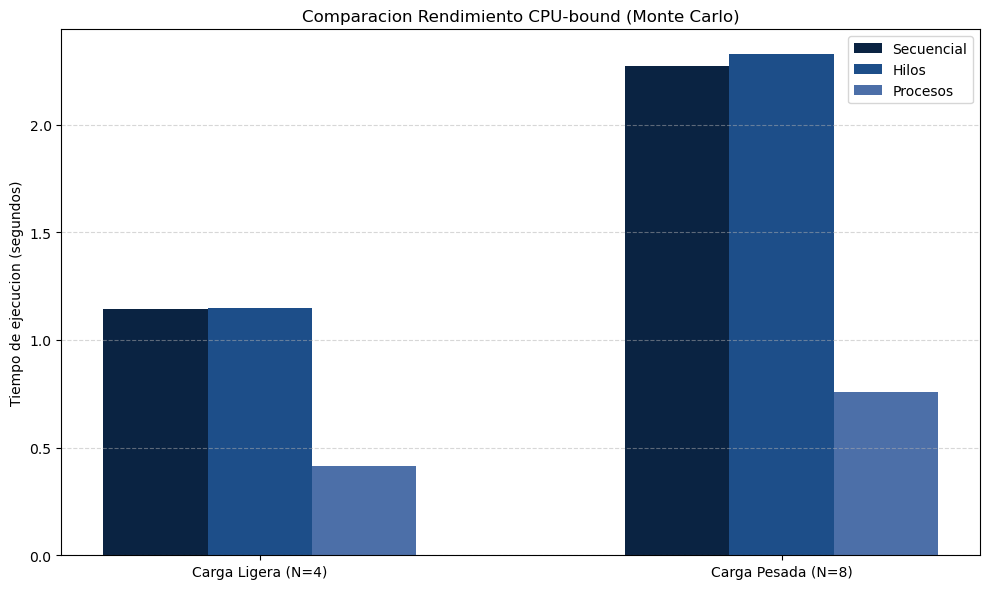

In [17]:
from funcion_monte_carlo import procesar_lote_simulaciones

def ejecutar_evaluacion_montecarlo():
    # 2 millones de dardos
    base = 2000000
    configuraciones = {
        "Carga Ligera (N=4)": [base] * 4,
        "Carga Pesada (N=8)": [base] * 8
    }
    
    resultados = []
    print("CPU-bound con  simulacion monte carlo\n")
    
    for nombre, lote in configuraciones.items():
        n_elem = len(lote)
        sub_lotes = [[x] for x in lote]
        
        # Secuencial
        inicio = time.perf_counter()
        procesar_lote_simulaciones(lote)
        t_sec = time.perf_counter() - inicio
        
        # Hilos 
        inicio = time.perf_counter()
        with ThreadPoolExecutor(max_workers=4) as executor:
            list(executor.map(procesar_lote_simulaciones, sub_lotes))
        t_hil = time.perf_counter() - inicio
        
        # Procesos
        inicio = time.perf_counter()
        with ProcessPoolExecutor(max_workers=4) as executor:
            list(executor.map(procesar_lote_simulaciones, sub_lotes))
        t_pro = time.perf_counter() - inicio
        
        resultados.append({
            "Configuracion": nombre,
            "N Lotes": n_elem,
            "Secuencial (s)": round(t_sec, 4),
            "Hilos (s)": round(t_hil, 4),
            "Procesos (s)": round(t_pro, 4)
        })
        
    df = pd.DataFrame(resultados)
    print(df.to_string(index=False))
    
    nombres = df["Configuracion"]
    x = range(len(nombres))
    ancho = 0.2
    
    plt.figure(figsize=(10, 6))
    plt.bar([p - ancho for p in x], df["Secuencial (s)"], width=ancho, label='Secuencial', color='#0A2342')
    plt.bar(x, df["Hilos (s)"], width=ancho, label='Hilos', color='#1D4E89')
    plt.bar([p + ancho for p in x], df["Procesos (s)"], width=ancho, label='Procesos', color='#4C6FA8')
    
    plt.title('Comparacion Rendimiento CPU-bound (Monte Carlo)')
    plt.ylabel('Tiempo de ejecucion (segundos)')
    plt.xticks(x, nombres)
    plt.legend()
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

if __name__ == '__main__':
    ejecutar_evaluacion_montecarlo()

Los resultados muestran como Python maneja las tareas pesadas de calculo en este caso cpu bound. En la carga pesada la ejecucion secuencial tardo 2.65 segundos y con hilos subio a 2.82 segundos ya que los hilos no sirven para acelerar calculos pesados por culpa del GIL de Python.

En cambio usar procesos bajo el tiempo a 0.73 segundos, ya que al crear procesos separados el programa logra saltarse el GIL, pedir memoria independiente y usar varios nucleos reales al mismo tiempo,pero esto solo sirve para tareas pesadas como se vio en el ejercicio 1, porque crear procesos gasta muchos recursos y memoria y produce el overhead.

Para que usar procesos valga la pena los grupos de datos deben ser muy grandes, es decir granularidad gruesa. Si el problema se divide en partes muy pequeñas el cpu gastara mas tiempo preparando los procesos que resolviendo el calculo. Ademas agregar mas procesos no siempre lo hace mas rapido por que casi siempre hay partes del codigo que son secuenciales, el cpu gasta tiempo extra creando cada proceso nuevo, y si pones mas procesos que los nucleos fisicos el equipo se vuelve mas lento intentando manejar todo a la vez.

<div align="center">
  <p style="font-size:11px; color:#8a8a8a; margin:6px 0 0 0;">
    Equipo utilizado: AMD Ryzen 7 5700X | 16 GB RAM | NVIDIA GeForce RTX 4060
  </p>
</div>